## Support Vector Machine (SVM)

- It's a classification algorithm
- Finds the optimal hyperplane that best separates the classes in the feature space
- Can be used for both linear and non-linear classification tasks
- Uses kernel functions to handle non-linear data by mapping it to a higher-dimensional space
- Common kernels include linear, polynomial, and radial basis function (RBF)
  
### Real-world applications of SVM: 
- Image classification
- Text categorization
- Bioinformatics (e.g., gene classification)
- Handwritten digit recognition 
- Financial Modeling

## Core Idea: 
- SVM finds the best possible boundary between classes by maximizing the margin 
- The margin is the distance between the hyperplane and the nearest data points from each class (called support vectors)
  
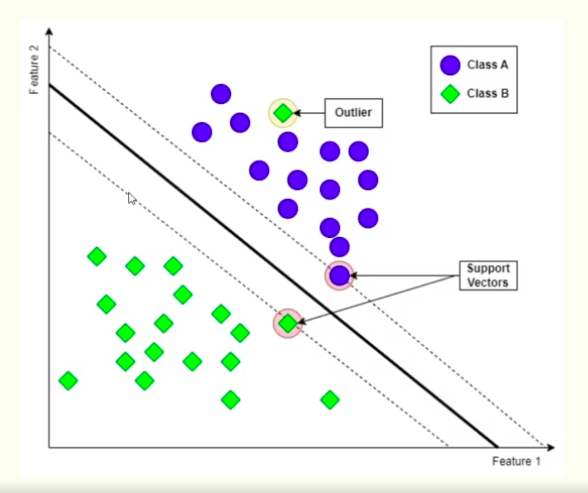

- Think of it as drawing the widest possible road between two neightborhoods --the wider the road, the clearest the separation. 

# Why Margin Matters: 
- The margin the distance from the decision boundary to the nearest data point on either side.
- **Bigger margin = better generalization**
- A wider margin means the model is confident about its classifications and less likely to misclassify new, unseen data.

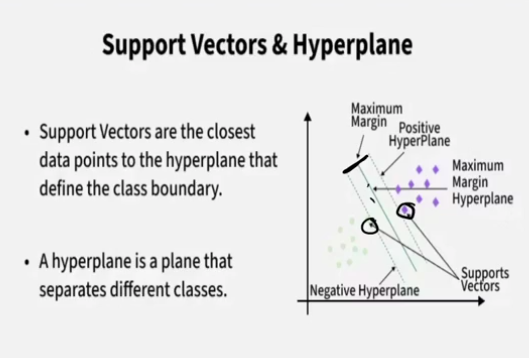

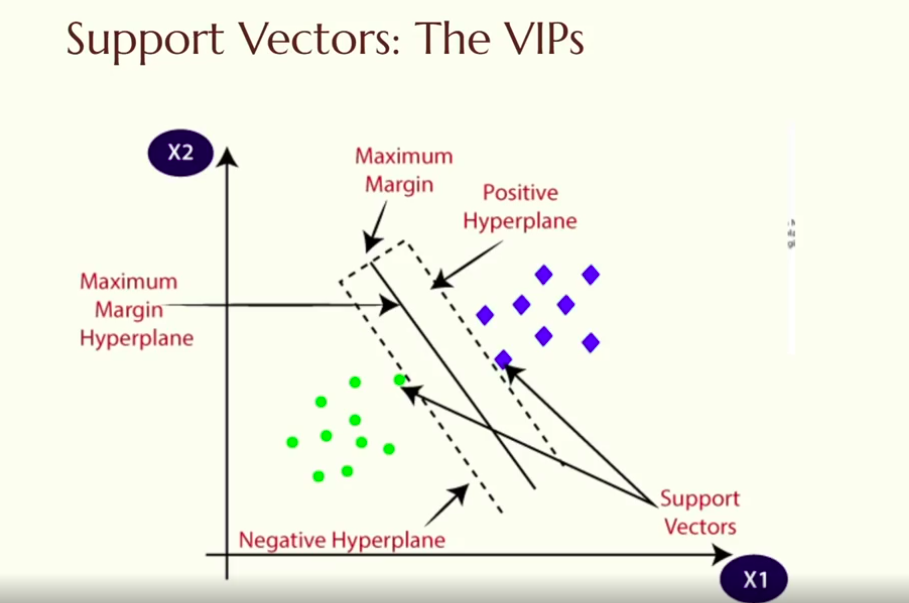

# Hard vs Soft Margin:
- **Hard Margin**: No misclassifications allowed, only works if data is perfectly linearly separable.
- **Soft Margin**: Allows some misclassifications to achieve better generalization on real-world data that is often noisy and not perfectly separable.

# Support Vectors:
- The data points that are closest to the decision boundary and influence its position and orientation.
- They are critical in defining the hyperplane and the margin.
- Removing a support vector can change the position of the hyperplane, while removing non-support vectors typically does not affect it.

# Hinge Loss:
- The loss function used in SVM to measure the error of predictions.
- It penalizes misclassifications and points that are within the margin.
- The goal of SVM is to minimize the hinge loss while maximizing the margin.    
- Formula: 
  
  $L(y, f(x)) = \sum_{i=1}^{N} \max(0, 1 - y_i f(x_i))$ 

- where $y_i$ is the true label and $f(x_i)$ is the predicted score.

# Understanding Kernels: 
- Kernels allow SVM to perform non-linear classification by implicitly mapping data to a higher-dimensional space.
- Common kernels include:
  - **Linear Kernel**: No transformation, used for linearly separable data.
  - **Polynomial Kernel**: Maps data to a higher-dimensional space using polynomial functions.
  - **Radial Basis Function (RBF) Kernel**: Maps data to an infinite-dimensional space, effective for non-linear data.
- The choice of kernel depends on the data and the problem at hand, and it can significantly impact the performance of the SVM model.   

# Why do we need kernels? 
- Many real-world datasets are not linearly separable in their original feature space.
- Kernels allow us to transform the data into a higher-dimensional space where it may become linearly separable, enabling SVM to find a hyperplane that can effectively separate the classes.

Different Kernels: 

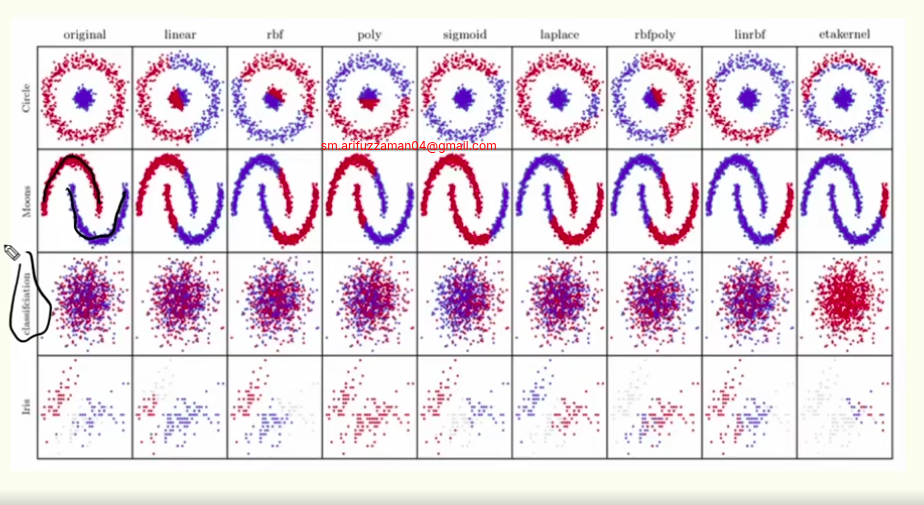

# The Kernel Trick:


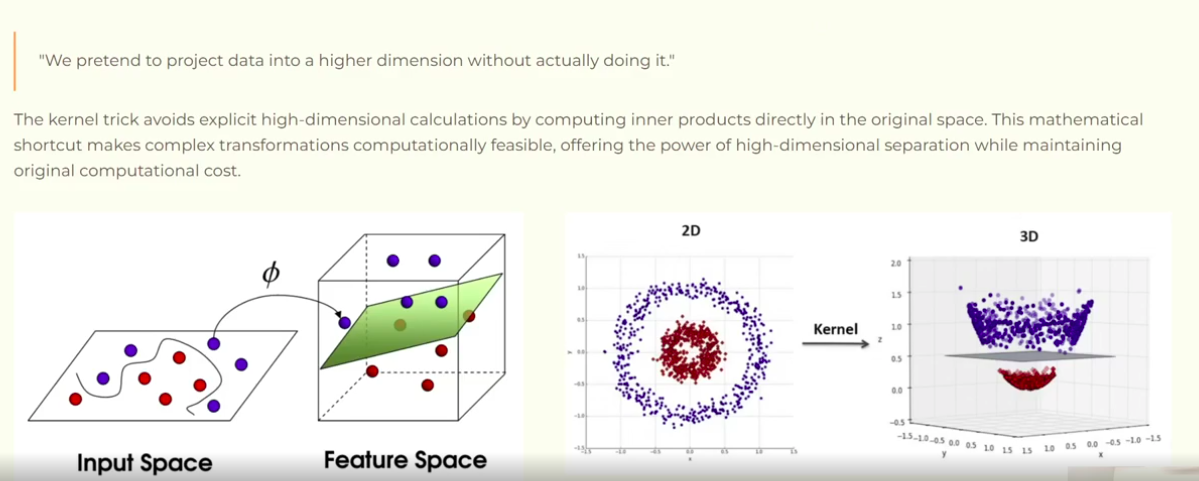



# Linear Kernel: 

Formula: 

$$K(x, x') = x^T x'$$

where:
- $x$ and $x'$ are two input vectors in the original feature space.
- $K(x, x')$ computes the dot product of the two vectors, which is equivalent to measuring their similarity in the original space.
> The linear kernel is suitable for linearly separable data and does not involve any transformation of the input features. It is computationally efficient and often used as a baseline for comparison with more complex kernels.

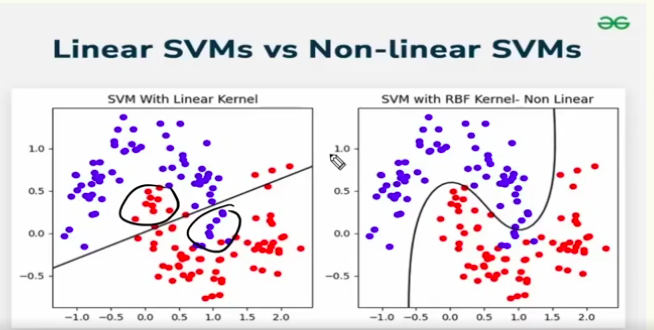

# Polynomial Kernel: 

Formula:

$$K(x, x') = (x^T x' + c)^d$$

where: 
- $x$ and $x'$ are two input vectors in the original feature space.
- $c$ is a constant that controls the influence of higher-order terms.
- $d$ is the degree of the polynomial, which determines the complexity of the decision boundary.
> The polynomial kernel allows for non-linear decision boundaries by mapping the input features into a higher-dimensional space. It can capture interactions between features, making it suitable for datasets where the relationship between features and classes is not linear.


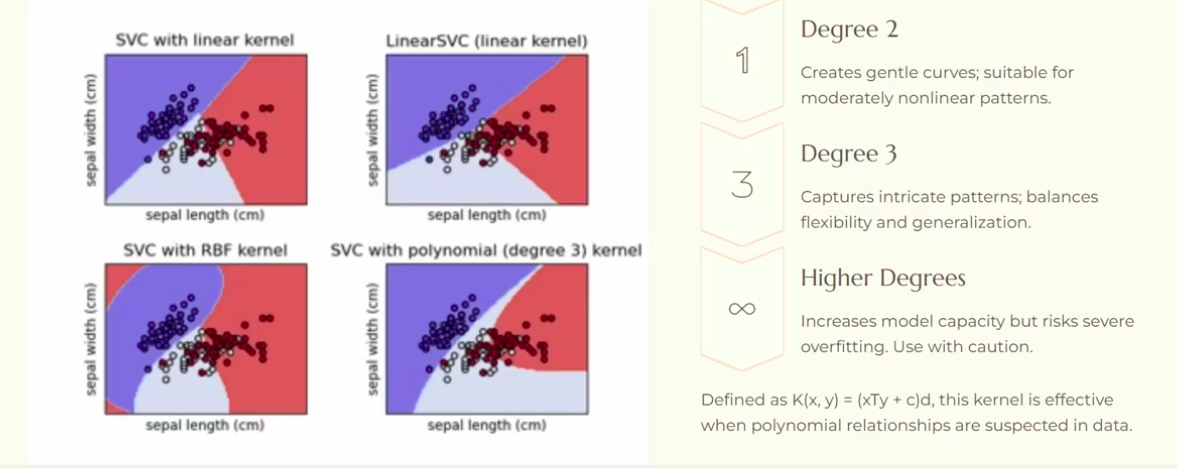 


# Polynomial Kernel trade-offs:
- **Pros**:
    - Can capture complex relationships between features.
    - Interpretable with clear degree
    - Effective for smooth patterns in data.
    - Less prone to overfitting than RBF for small datasets.
- **Cons**:
    - Can be computationally expensive for high-degree polynomials.
    - May not perform well if the true relationship is not polynomial.
    - Sensitive to outliers, which can significantly affect the decision boundary.
    - Requires careful tuning of the degree and constant parameters to avoid overfitting or underfitting. 
    - Not suitable for very high-dimensional data, as it can lead to the curse of dimensionality.
  
# Radial Basis Function (RBF) Kernel: 

Formula:
$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$

where:
- $x$ and $x'$ are two input vectors in the original feature space.
- $\gamma$ is a parameter that controls the width of the Gaussian function, which determines how much influence a single training example has on the decision boundary.
> The RBF kernel is a popular choice for non-linear classification tasks as it can capture complex relationships between features. It maps the input data into an infinite-dimensional space, allowing for highly flexible decision boundaries. However, it requires careful tuning of the $\gamma$ parameter to avoid overfitting or underfitting, and it can be computationalally expensive for large datasets.


- **Infinite Dimensions**
  - Maps data to an infinite-dimensional space, allowing for highly flexible decision boundaries.
- **Localized Influence**
  - Each training example has a localized influence on the decision boundary, determined by the $\gamma$ parameter.
- **Non-linear Decision Boundaries**
  - Can capture complex, non-linear relationships between features.


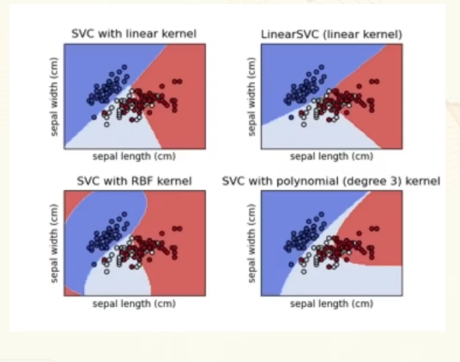


# The gamma parameter in RBF Kernel:

### Low gamma:
- **Wide influence**
  - Affects distant points
  - Smooth, generalized boundaries
  - Reduces overfitting
  - Risk of underfitting

### High gamma:
- **Narrow influence**
  - Affects only nearby points
  - Complex, wiggly boundaries
  - Increases risk of overfitting
- Risk of capturing noise in the data   

> Rule of thumb: Start with gamma = 1/n_features and adjust based on performance.

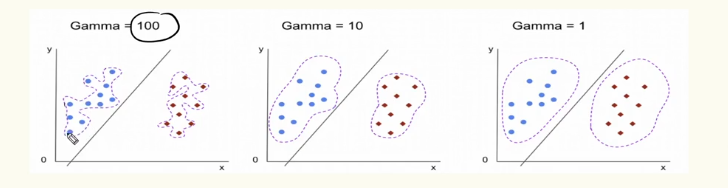

## When to use which kernel? 

- **Linear Kernel**: Use when data is linearly separable or when you have a large number of features relative to samples.
- **Polynomial Kernel**: Use when you suspect a polynomial relationship between features and classes, but be cautious of overfitting with high-degree polynomials.
- **RBF Kernel**: Use when data is not linearly separable and you want a flexible decision boundary, but be mindful of tuning the gamma parameter to avoid overfitting.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification, make_moons, make_circles, make_regression 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, SVR

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)


In [3]:
X_lin, y_lin = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    random_state=42
)

y_lin[:10]

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0])

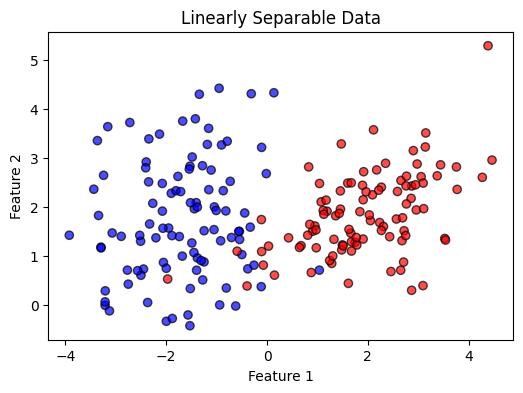

In [4]:
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap='bwr', edgecolor='k', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linearly Separable Data')
plt.show()

In [5]:
# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Train a linear SVM classifier
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("Accuracy: ", acc * 100, "%")

Accuracy:  97.5 %


In [7]:
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', alpha=0.8)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()
    


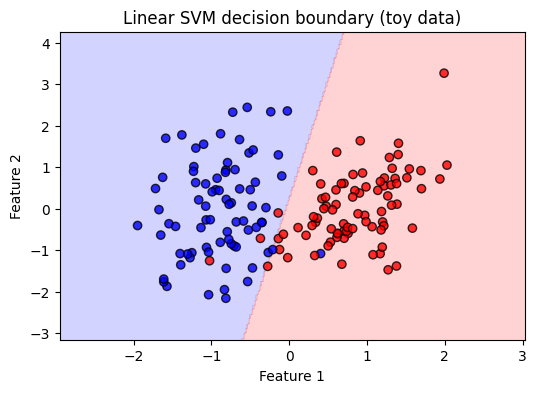

In [8]:
# Visualize the linear SVM boundary on scaled training data

plot_decision_boundary(svm_linear, X_train_scaled, y_train, title="Linear SVM decision boundary (toy data)")

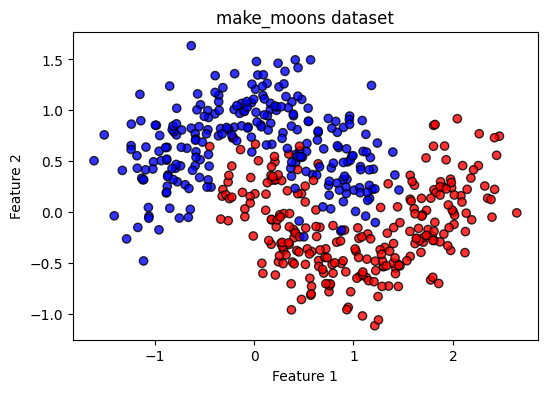

In [9]:
X_moon, y_moon = make_moons(n_samples=500, noise=0.25, random_state=42)

plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap='bwr', edgecolors='k', alpha=0.8)
plt.title("make_moons dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [10]:
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moon, y_moon, test_size=0.2, random_state=42
)

scaler_moon = StandardScaler()
X_moon_train_scaled = scaler_moon.fit_transform(X_moon_train)
X_moon_test_scaled = scaler_moon.transform(X_moon_test)

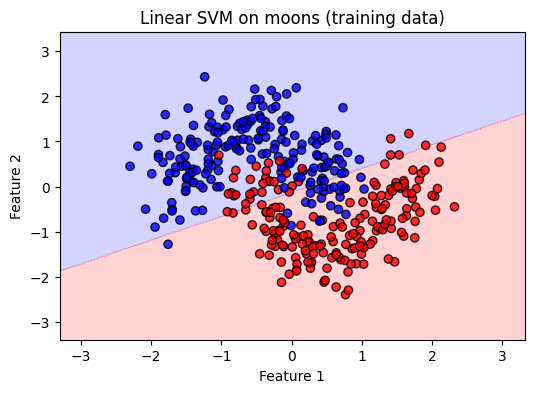

Accuracy (linear kernel on moons):  86.0


In [11]:
# Linear Kernel on Moons
svc_linear_moon = SVC(kernel='linear', C=1.0, random_state=42)
svc_linear_moon.fit(X_moon_train_scaled, y_moon_train)
plot_decision_boundary(svc_linear_moon, X_moon_train_scaled, y_moon_train, title='Linear SVM on moons (training data)')

print('Accuracy (linear kernel on moons): ', accuracy_score(y_moon_test, svc_linear_moon.predict(X_moon_test_scaled)) * 100)


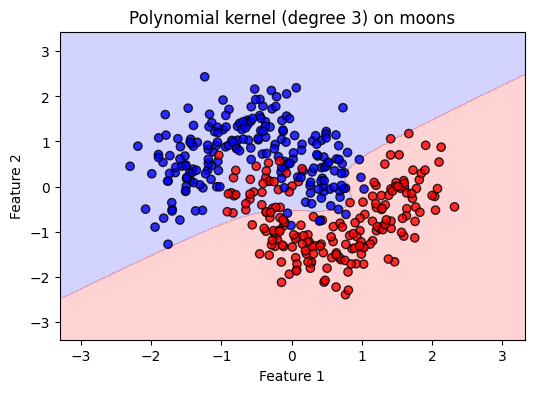

Accuracy (RBF kernel on moons):  85.0


In [12]:
# Polynomial kernel on moons
svc_poly_moon = SVC(kernel='poly', degree=3, C=20.0, gamma='scale', random_state=42)
svc_poly_moon.fit(X_moon_train_scaled, y_moon_train)

plot_decision_boundary(svc_poly_moon, X_moon_train_scaled, y_moon_train, title='Polynomial kernel (degree 3) on moons')

print("Accuracy (RBF kernel on moons): ", accuracy_score(y_moon_test, svc_poly_moon.predict(X_moon_test_scaled)) * 100)


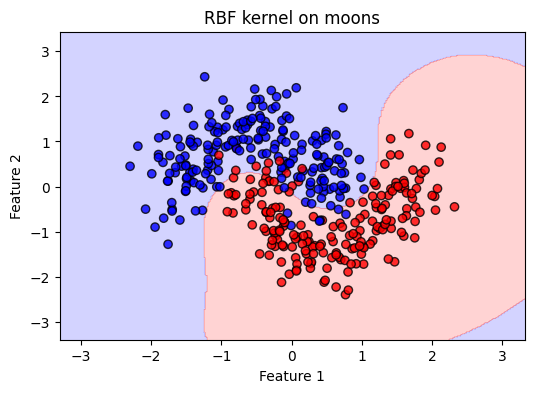

Accuracy (RBF Kernel on moons):  93.0


In [13]:
svc_rbf_moon = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_rbf_moon.fit(X_moon_train_scaled, y_moon_train)

plot_decision_boundary(svc_rbf_moon, X_moon_train_scaled, y_moon_train, title='RBF kernel on moons')

print("Accuracy (RBF Kernel on moons): ", accuracy_score(
    y_moon_test,
    svc_rbf_moon.predict(X_moon_test_scaled)
) * 100)

# SVM on REAL DATA:

In [14]:
cancer = load_breast_cancer()
X_bc = cancer.data
y_bc = cancer.target

print("Feature Shape: ", X_bc.shape)
print("Classes: ", cancer.target_names)


Feature Shape:  (569, 30)
Classes:  ['malignant' 'benign']


In [15]:
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()

X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
X_bc_test_scaled = scaler_bc.transform(X_bc_test)

In [16]:
# Train an RBF SVM classifier on breast cancer data
svc_rbf_bc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# svc_rbf_bc = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)

svc_rbf_bc.fit(X_bc_train_scaled, y_bc_train)
y_bc_pred = svc_rbf_bc.predict(X_bc_test_scaled)

acc_bc = accuracy_score(y_bc_test, y_bc_pred)
print("Breast Cancer SVM Accuracy: ", round(acc_bc, 4) * 100, "%")
print("Classification Report:")
print(classification_report(y_bc_test, y_bc_pred, target_names=cancer.target_names))


Breast Cancer SVM Accuracy:  98.25 %
Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [18]:
# Confusion Matrix
cm = confusion_matrix(y_bc_test, y_bc_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[41  1]
 [ 1 71]]


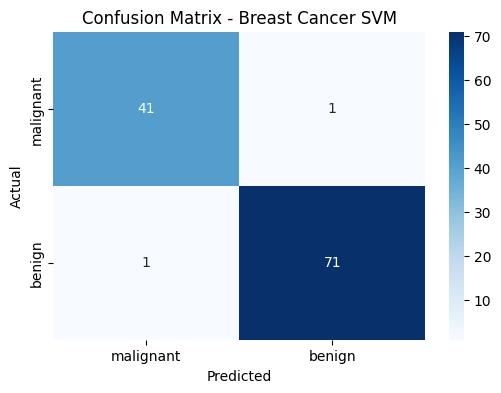

In [19]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix - Breast Cancer SVM')
plt.show()

In [23]:
def evaluate_svm_c_gamma(X_train, X_test, y_train, y_test, C_values, gamma_values):       
    results = []
    
    for C in C_values:
        for gamma in gamma_values:
            model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            results.append({
                'C': C,
                'gamma': gamma,
                'accuracy': acc
            })
    
    return pd.DataFrame(results)


C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 0.01, 0.1, 1.0]

df_hyper = evaluate_svm_c_gamma(
    X_bc_train_scaled,
    X_bc_test_scaled,
    y_bc_train,
    y_bc_test,
    C_values,
    gamma_values
)

df_hyper 

,C,gamma,accuracy
0,0.1,scale,0.947368
1,0.1,0.01,0.956140
2,0.1,0.1,0.947368
3,0.1,1.0,0.631579
4,1.0,scale,0.982456
5,1.0,0.01,0.982456
6,1.0,0.1,0.956140
7,1.0,1.0,0.631579
8,10.0,scale,0.973684
9,10.0,0.01,0.982456


In [24]:
df_hyper.sort_values(by='accuracy', ascending=False)

,C,gamma,accuracy
5,1.0,0.01,0.982456
4,1.0,scale,0.982456
9,10.0,0.01,0.982456
8,10.0,scale,0.973684
13,100.0,0.01,0.964912
1,0.1,0.01,0.956140
6,1.0,0.1,0.956140
0,0.1,scale,0.947368
12,100.0,scale,0.947368
10,10.0,0.1,0.947368
